# ResNet-18 (Naive — Frozen Backbone)

In [29]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [30]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [31]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=True).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Positive weight: tensor([6.0244], device='mps:0')


In [32]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/resnet_naive_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8649, Acc: 0.7361, Recall: 0.7856, F2: 0.6114 | Val Loss: 0.7820, Acc: 0.7204, Recall: 0.8982, F2: 0.6643
Saved best model at epoch 1
Epoch [2/20] | Train Loss: 0.7372, Acc: 0.7725, Recall: 0.8370, F2: 0.6672 | Val Loss: 0.7736, Acc: 0.6931, Recall: 0.9042, F2: 0.6492
Epoch [3/20] | Train Loss: 0.6931, Acc: 0.7897, Recall: 0.8408, F2: 0.6826 | Val Loss: 0.7948, Acc: 0.6795, Recall: 0.9162, F2: 0.6467
Epoch [4/20] | Train Loss: 0.6817, Acc: 0.7891, Recall: 0.8370, F2: 0.6799 | Val Loss: 0.7181, Acc: 0.7801, Recall: 0.8323, F2: 0.6702
Saved best model at epoch 4
Epoch [5/20] | Train Loss: 0.6947, Acc: 0.7918, Recall: 0.8306, F2: 0.6782 | Val Loss: 0.7636, Acc: 0.6914, Recall: 0.9222, F2: 0.6576
Epoch [6/20] | Train Loss: 0.6766, Acc: 0.7942, Recall: 0.8395, F2: 0.6854 | Val Loss: 0.7085, Acc: 0.7528, Recall: 0.8443, F2: 0.6570
Epoch [7/20] | Train Loss: 0.6601, Acc: 0.7990, Recall: 0.8370, F2: 0.6876 | Val Loss: 0.6985, Acc: 0.8065, Recall: 0.8204, F2: 0.6836

## Plot Loss and Accuracy Curves

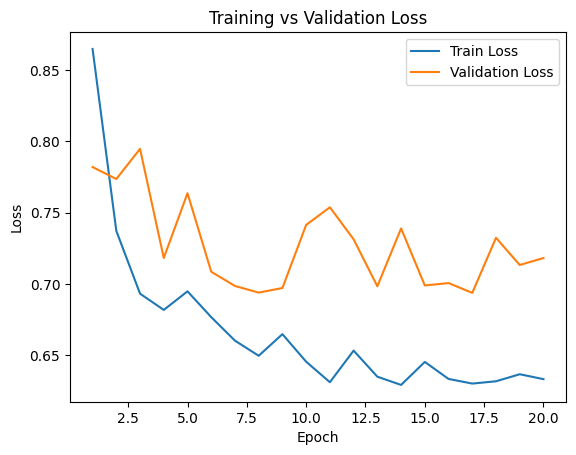

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

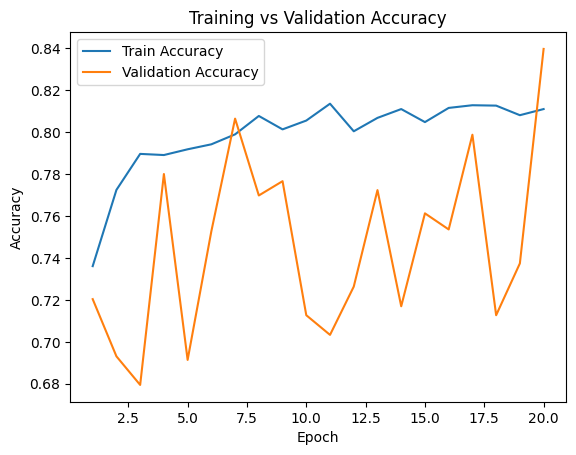

In [34]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

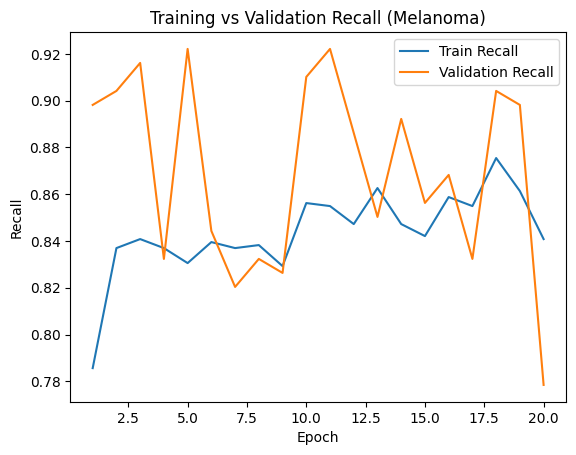

In [35]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

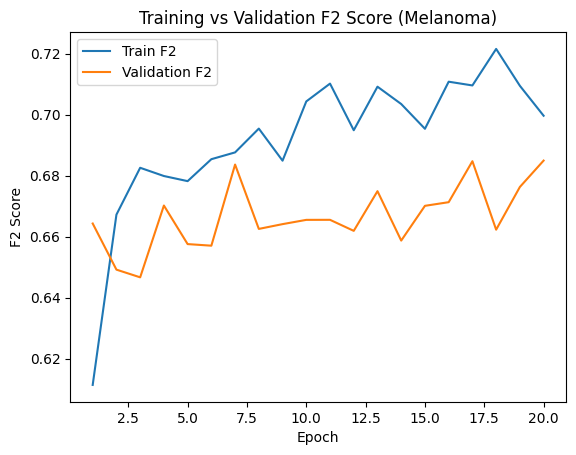

In [36]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [37]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('../models/resnet_naive_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.46 | Val F2: 0.6872


In [38]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load('../models/resnet_naive_best.pth', map_location=device))
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [39]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[851 155]
 [ 32 135]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [40]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9638    0.8459    0.9010      1006
           1     0.4655    0.8084    0.5908       167

    accuracy                         0.8406      1173
   macro avg     0.7146    0.8272    0.7459      1173
weighted avg     0.8928    0.8406    0.8568      1173



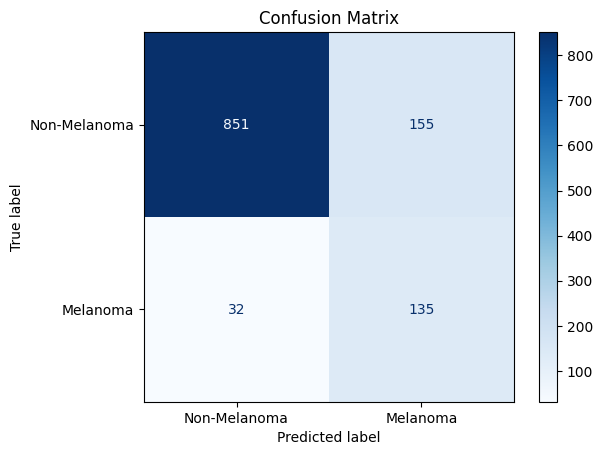

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()